# VQC Based on IQC and IQC:AIL

## Imports

In [2]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit
from qiskit.compiler import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane
import qutip

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.model_selection import StratifiedKFold,train_test_split
from sklearn.datasets import make_blobs
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pdflatex

import pandas as pd


## Base de Dados

In [3]:
#Parâmetros
RANDOM_SEED = 42
N_SAMPLES = 300
N_FEATURES = 6
N_PRINTINGS = N_SAMPLES//10
LEARNING_RATE = 0.01
RESPONSE_METHOD = "predict"
results = []

In [4]:
#Gerando o dataset
def generate_blobs(normalize_col=False, normalize_lin=False):
  X, y = make_blobs(n_samples=N_SAMPLES, n_features=N_FEATURES, centers=10, random_state=RANDOM_SEED,cluster_std=0.7)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
    X = X - 1
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

X_blobs,y_blobs=generate_blobs(normalize_col=True)

## Estratificando o dataset

In [5]:
#Gerando os datasets de treino e teste
X_train, X_test, y_train, y_test=train_test_split(X_blobs,y_blobs,test_size=0.3,train_size=0.7)

In [6]:
#Plotando os dados em que N_features==2
if N_FEATURES==2:
    plt.figure(figsize=(8, 8))
    plt.title("Exemplo simples de base de dados Moons", fontsize="small")
    plt.scatter(X_blobs[:, 0], X_blobs[:, 1], marker="o", s=25, c=y_blobs, edgecolor="k")
    plt.savefig("Dataset_blobs.png", dpi=1500)
    plt.show()

## Quantum Circuit

Não geraremos imagens ainda

X[105]: [np.float64(-0.18465144642914977), np.float64(-0.8739144741381156), np.float64(-0.8872768857705942), np.float64(-0.17583878074905168), np.float64(-0.09075531270880832), np.float64(-0.16387172318792254), np.float64(-0.1612775860912964), np.float64(-0.8531247582871945), np.float64(-0.3448640971874013), np.float64(-0.3985484567814612), 0, 0, 0, 0, 0, 0] ; w: [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0] 

sigmaE
[[-0.18465145  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.         -0.87391447  0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.         -0.88727689  0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.         -0.1

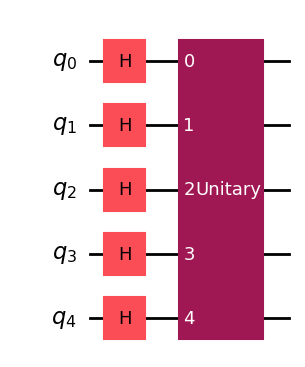

In [5]:
# Criando o circuito com um vetor qualquer do dataset para exemplificar

N_atributos=N_FEATURES 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
#Escolhendo uma linha aleatória de X para podermos debugar
lista=[i for i in range(len(X_blobs))]
j=int(np.random.choice(lista))

w=np.full(N_atributos,1)

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

# IQC

qc = QuantumCircuit(N_qubits)
qc.h(0) # Inicializaçao do estado inicial. Poderia ser qualquer estado.
qc.h(range(1,N_qubits))



#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_blobs_new=list(X_blobs[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_blobs_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_blobs_new)*w.T
else:
    sigmaE=np.diag(X_blobs_new)*w.T

#Debugando
print(f'X[{j}]:', X_blobs_new, '; w:', w,'\n')
print('sigmaE')
print(sigmaE)
#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

qubits=[i for i in range(N_qubits)]
# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,qubits)
qc.draw("mpl")

In [6]:
#Decompondo em portas U3 e CX
qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
print(dict(qc.count_ops()))
if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
    display(qc.draw('mpl'))

{'u3': 364, 'cx': 242}


### Statevector e Matriz Densidade

Aqui vamos avaliar o estado depois da evolução 

#### Statevector

<IPython.core.display.Latex object>

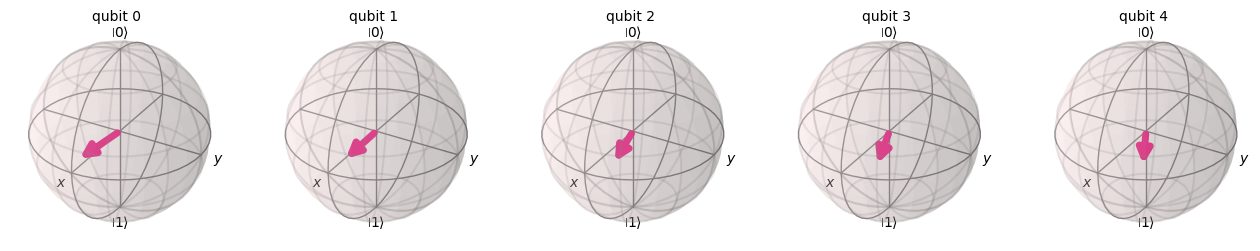

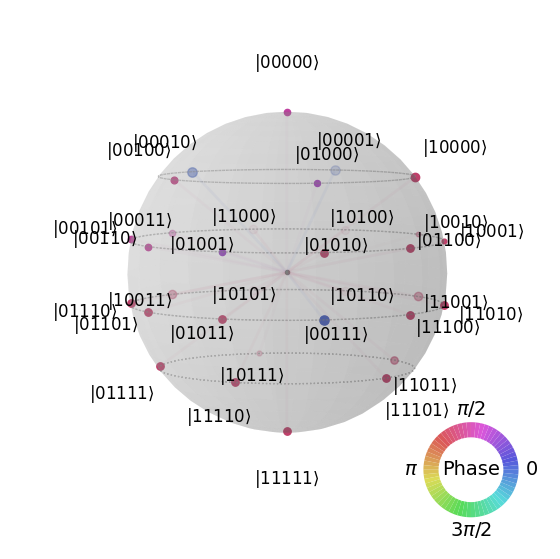

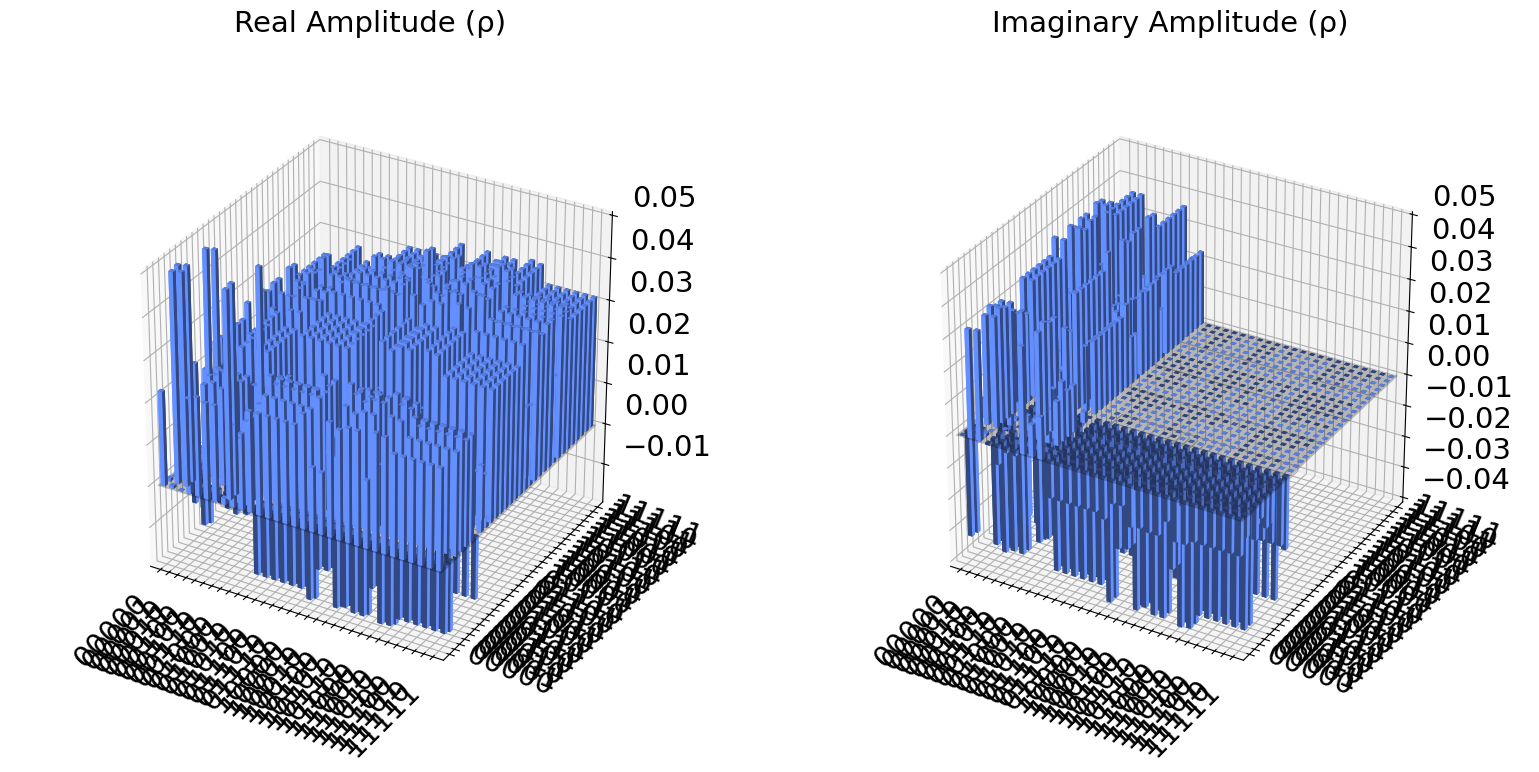

In [7]:
#Estado completo
sv = Statevector(qc)
'''
'mpl' is not a valid option for drawing Statevector objects. Please choose from:
            'text', 'latex', 'latex_source', 'qsphere', 'hinton',
            'bloch', 'city' or 'paulivec'
'''

display(sv.draw("latex")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("bloch")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("qsphere")) #Plota o vetor de estado em uma esfera que mapeia o espaço tensorial originado pelos espaços de Hilbert
display(sv.draw("city")) #Plota o histograma da matriz densidade SEM MEDÍ-LA


#### Partial Trace

Vamos traçar o sis. auxiliar

In [8]:
rho = partial_trace(sv,qubits[1:])
print(rho)

def blochvector(rho):
    x = np.trace(matriz_pauli_x@rho.data)
    y= np.trace(matriz_pauli_y@rho.data)
    z = np.trace(matriz_pauli_z@rho.data)
    return [x,y,z]
blochvector(rho)


DensityMatrix([[0.5       -8.00619794e-19j, 0.37823829+4.10326997e-02j],
               [0.37823829-4.10326997e-02j, 0.5       +7.05019275e-19j]],
              dims=(2,))


[np.complex128(0.7564765895138966+6.938893903907228e-18j),
 np.complex128(-0.0820653993286736+0j),
 np.complex128(9.880984919163893e-15-1.50563906860003e-18j)]

#### Ponto na Casca da superfície da Esfera de Bloch

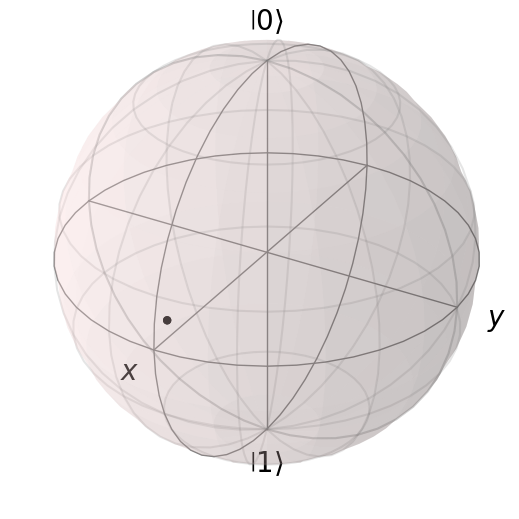

In [9]:
b = qutip.Bloch()
b.point_default_color=['k']
b.add_points(blochvector(rho))

b.render()
b.show()

#### Matriz Densidade

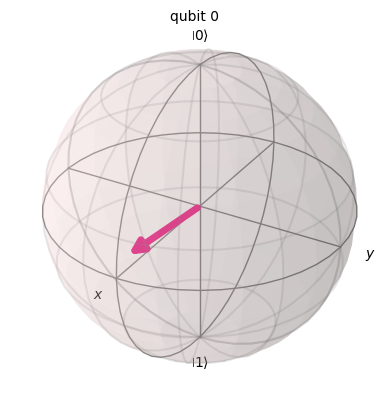

In [10]:
# Ao traçar fora o ambiente

rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
#rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:]).data

display(rho_res.draw('bloch'))


Como podemos observar, conseguimos marcar o ponto, na superfície da esfera, ao qual o autovetor do SISTEMA pertence. E se fizermos isso durante todo o código?

### Executando o Circuito

{'00001': 46, '11000': 39, '01111': 38, '00110': 28, '11101': 39, '10011': 42, '10101': 43, '11010': 30, '00111': 51, '11001': 35, '11100': 29, '10110': 48, '10000': 42, '00010': 60, '01000': 17, '10100': 34, '00101': 27, '11111': 32, '01110': 21, '00011': 25, '11110': 26, '01011': 30, '00000': 24, '01010': 27, '10111': 24, '01101': 34, '01001': 21, '00100': 27, '11011': 30, '01100': 29, '10010': 11, '10001': 15}


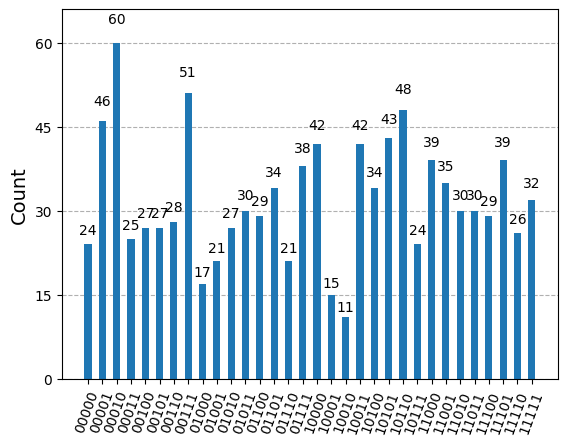

In [11]:
#Executar o circuito
def run_qasm_counts(circ, shots=1024):
  qc.measure_all()
  qasm_simulator = Aer.get_backend("qasm_simulator")
  job = qasm_simulator.run(qc, shots=shots)
  result = job.result()
  return result.get_counts()

counts = run_qasm_counts(qc)
print(counts)
plot_histogram(counts)

## Função que junta tudo até agora

In [22]:
def cirq(data,contador,N_atributos,printar_cirq=False):
    '''
    Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
    '''
    w=np.full(N_atributos,1)
    

    #x=np.random.rand(N_atributos)
    #w=np.random.rand(N_atributos)

    N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC

    qc = QuantumCircuit(N_qubits)
    qc.h(0) # Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(range(1,N_qubits))



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    X_blobs_new=list(data)
    if np.log2(N_atributos)%2:
        for k in range(2**(N_qubits-1) - N_atributos):
            X_blobs_new.append(0)
            w=np.append(w,0)
        sigmaE=np.diag(X_blobs_new)*w.T
    else:
        sigmaE=np.diag(X_blobs_new)*w.T

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    qubits=[i for i in range(N_qubits)]
    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_complete_U{contador}_blobs.png')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50 and contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{contador}_blobs.png')

    if printar_cirq==True and dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador%N_PRINTINGS==0:
        sv.draw("city", filename=f'./state_vector_city{contador}_blobs.png')
        sv.draw("bloch", filename=f'./state_vector_bloch{contador}_blobs.png')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{contador}_blobs.png')
    if printar_cirq==True:
        display(sv.draw("latex"))

    rho = partial_trace(sv,qubits[1:])
    if printar_cirq==True:
        print(rho)

    def blochvector(rho):
        x = np.trace(matriz_pauli_x@rho.data)
        y= np.trace(matriz_pauli_y@rho.data)
        z = np.trace(matriz_pauli_z@rho.data)
        return [x,y,z]
    
    #Executar o circuito
    def run_qasm_counts(circ, shots=1024):
        qc.measure_all()
        qasm_simulator = Aer.get_backend("qasm_simulator")
        job = qasm_simulator.run(qc, shots=shots)
        result = job.result()
        return result.get_counts()

    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_blobs.png')
    


    return blochvector(rho)

## Esfera de Bloch do Circuito

In [30]:
print(b)

Bloch data:
-----------
Number of points:  1
Number of vectors: 0

Bloch sphere properties:
------------------------
font_color:      black
font_size:       20
frame_alpha:     0.2
frame_color:     gray
frame_width:     1
point_default_color:['k']
point_marker:    ['o']
point_size:      [15, 15, 15, 15]
sphere_alpha:    0
sphere_color:    #FFDDDD
figsize:         [5, 5]
vector_default_color:['g', '#CC6600', 'b', 'r']
vector_width:    3
vector_style:    -|>
vector_mutation: 20
view:            [-60, 30]
xlabel:          ['$x$', '']
xlpos:           [1.2, -1.2]
ylabel:          ['$y$', '']
ylpos:           [1.2, -1.2]
zlabel:          ['$\\left|0\\right>$', '$\\left|1\\right>$']
zlpos:           [1.2, -1.2]



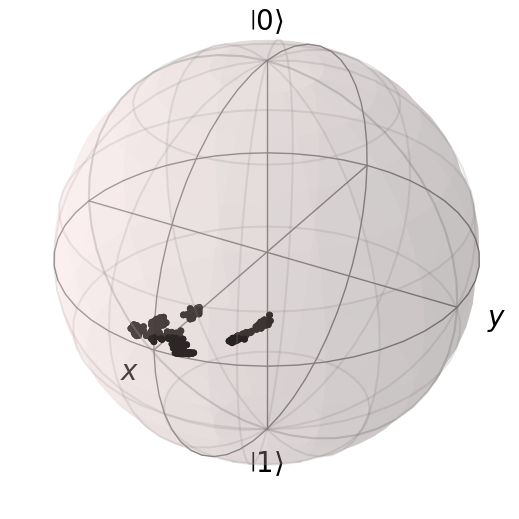

In [23]:
def esfera_bloch_CQ(X_blobs,counter):
    point_states=[]
    for k in range(0,N_SAMPLES):
        point_states.append(cirq(X_blobs[k],k,N_FEATURES))

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[15, 15, 15, 15]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    b.show()

    bb = b.fig
    bb.savefig(f'Bloch_geral_blobs{counter}.png')

esfera_bloch_CQ(X_blobs,1)

## IQC

In [3]:
def IQC(x,w):
  n = len(x)

  #from sympy.physics.matrices import msigma(indice)

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE

## IQC:AIL

In [ ]:
def IQC_AIL(x,w):
  n = len(x)
  norma_x=np.linalg.norm(x)+1e-16 #To avoid zero division

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T #No fim, é uma matriz composta apenas por pesos

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE